**Image segmentation using fuzzyc-means clustering**

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray
import skfuzzy as fuzz
from ipywidgets import interact, widgets
from IPython.display import display
import requests

In [17]:
import requests
from io import BytesIO

url = 'https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
image = io.imread(BytesIO(response.content))

image

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], shape=(600, 800, 4), dtype=uint8)

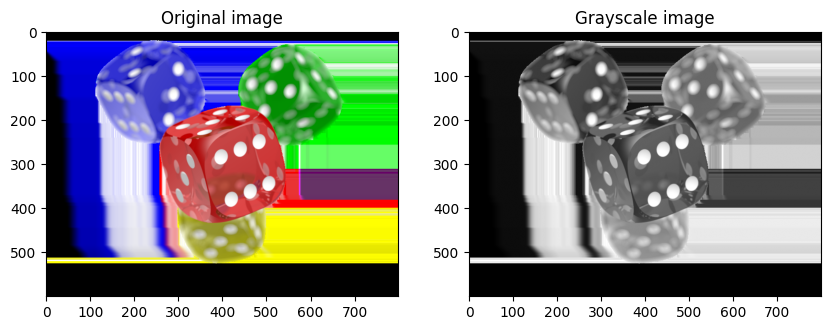

In [18]:
# considering only three channel (RGB)

if image.shape[-1] == 4:
  image = image[..., :3]

gray_image = rgb2gray(image)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title('Original image')
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.title('Grayscale image')
plt.imshow(gray_image, cmap='gray')
plt.show()

In [21]:
# now we reshape the gray-scale image to 1-d array of pixels

pixels = gray_image.reshape(-1, 1)

# Apply fuzzy c-means clustering
n_clusters = 3

cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
  pixels.T, n_clusters, 2, error=0.005, maxiter=1000, init=None
)

cluster_membership = np.argmax(u, axis=0)

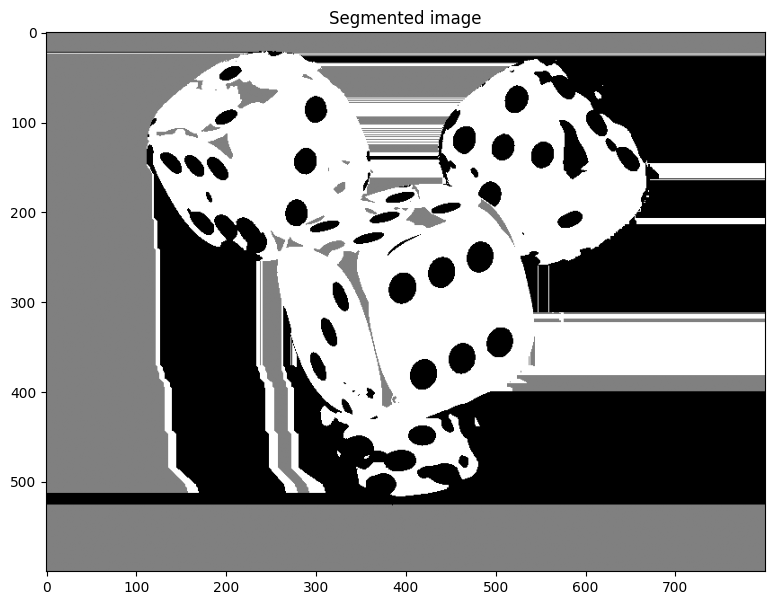

In [23]:
# Reshape the cluster data back to image shape

segmented_image = cluster_membership.reshape(gray_image.shape)

plt.figure(figsize=(12, 7))
plt.title('Segmented image')
plt.imshow(segmented_image, cmap='gray')
plt.show()

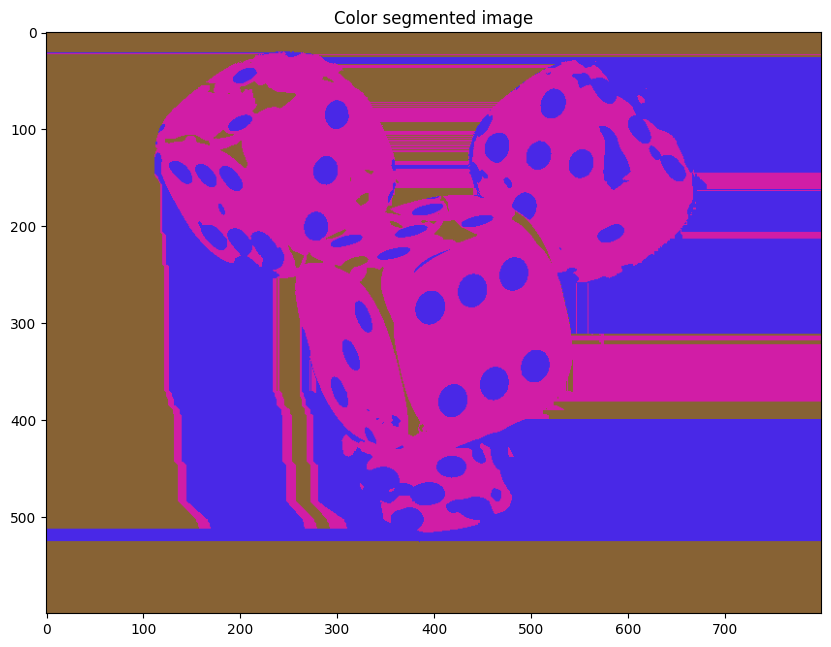

In [24]:
# Assign color to each cluster

colored_segmented_image = np.zeros((gray_image.shape[0], gray_image.shape[1], 3))

for i in range(n_clusters):
  colored_segmented_image[segmented_image == i] = np.random.rand(3)

plt.figure(figsize=(10, 8))
plt.imshow(colored_segmented_image)
plt.title('Color segmented image')
plt.show()

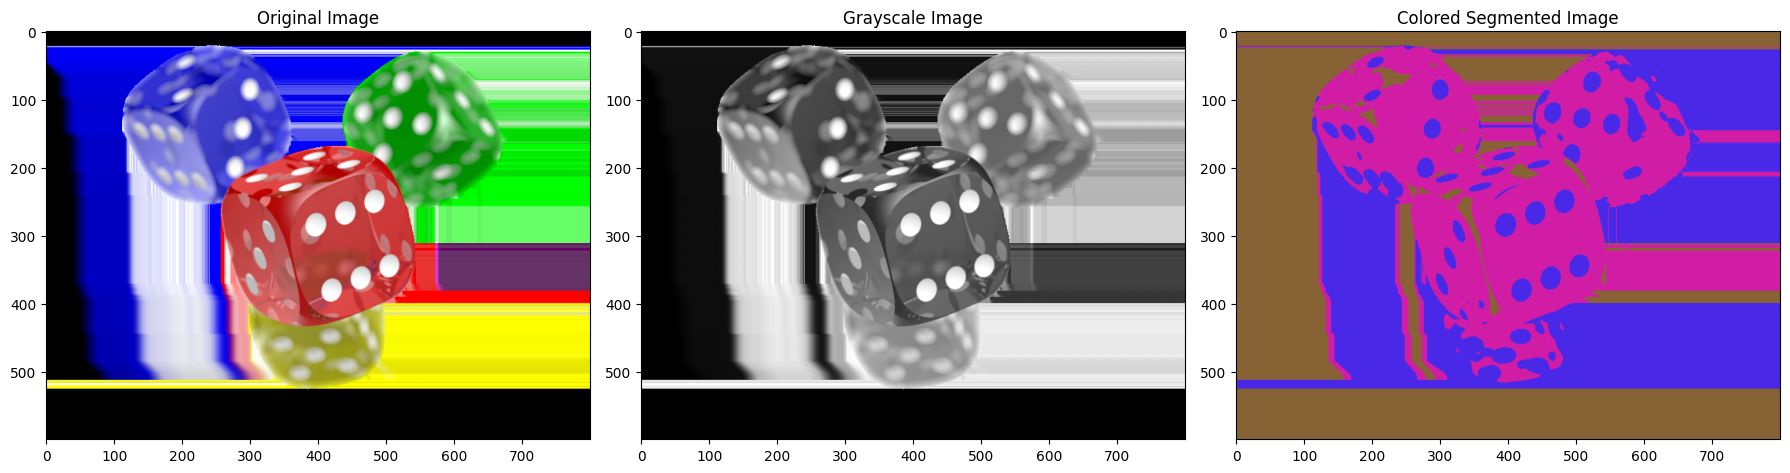

In [27]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.subplot(1, 3, 3)
plt.imshow(colored_segmented_image)
plt.title('Colored Segmented Image')
plt.tight_layout()
plt.show()

In [ ]:
# Create the widgets
url_widget = widgets.Text(
  value='https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png',
  description='Image URL:',
  layout=widgets.Layout(width='80%')
)
clusters_widget = widgets.IntSlider(
  value=3,
  min=2,
  max=10,
  step=1,
  description='Clusters:'
)

# Use the interact function to create the GUI
interact(segmented_image, url=url_widget, n_clusters=clusters_widget)